In [3]:
import numpy as np
import pandas as pd
from utils.modeling_utilities import * 
from utils.models import *
from utils.metrics import *
import joblib
from config.global_vars import * 

## Operational Use Case: Escalation Model

#### Preprocessing

In [4]:
## Build Label
raw_inc= pd.read_csv(INCIDENTS_PATH, dtype=str, keep_default_na=False, na_values=[])
inc = raw_inc[raw_inc.type_of_incident == 'train'].copy()
inc['label'] = inc.incident_duration_band.isin(MAJOR_BANDS).astype(int)
inc['service_day'] = pd.to_datetime(inc.calendar_day)
inc['start_min'] = to_minutes(inc.time_of_incident)
inc['time_stamp'] = inc.service_day + pd.to_timedelta(inc.start_min, unit='m')
inc.sort_values('time_stamp').reset_index(drop=True, inplace= True)

#### Features Derivation

The idea is to only include features that are knowable when the incident starts, namely the antecedents. 
This is meant to mimic a realistic scenario and avoid data leakage

In [5]:

### Fields that are consequences are used in post-hoc analysis, or the label itself.
CONSEQUENTS = ['evacuation', 'emergency_metro', 'material_damage', 'cat', 'kfs', 'door',
         'primary_cause', 'secondary_cause', 'resumption_time',
         'incident_duration_band']

CATEGORICAL = ['line_primary', 'station', 'symptom', 'hardware_type']


In [6]:
inc['hour'] = (inc.start_min // 60 % 24).astype(int)
inc['dow'] = inc.service_day.dt.dayofweek
inc['month'] = inc.service_day.dt.month
inc['is_weekend'] = inc.dow.isin([5, 6]).astype(int)
inc['is_peak'] = (inc.hour.isin([7, 8, 16, 17]) & ~inc.is_weekend.astype(bool)).astype(int)
inc['is_night'] = (inc.start_min >= 24 * 60).astype(int)   # true post-midnight

In [7]:
# multi-line incidents
inc['n_lines'] = inc.line.apply(
        lambda v: 1 if v in SINGLE_LINES else (np.nan if v == 'unassigned' else len(v.split('_'))))
inc['is_multi_line'] = (inc.n_lines > 1).astype(int)
inc['line_primary'] = inc.line.str.split('_').str[0]

In [8]:
## location handler
inc['station'] = inc.location_code.str.split(' - Ligne').str[0].str.strip()
inc['loc_freq'] = inc.groupby('station').station.transform('size')

## hardware clean missing values if any
inc['hardware_type'] = inc.hardware_type.replace('', 'unassigned')

## route handler
inc['route_known'] = (inc.route != 'N/A').astype(int)

In [9]:
## Time series features
inc = inc.sort_values('time_stamp')
#the number of incidents on the same line in the last 24 hours and the last 7 days (168 hours)
for hours, feat_name in [(24, 'inc_24h'), (168, 'inc_7d')]:
    feat_value = pd.Series(index=inc.index, dtype=float)
    for group_idx, group_data in inc.groupby('line_primary'):

        ## counts the non null labels in rolling window of [t-{hours}, t)
        counts = group_data.set_index('time_stamp').label.rolling(f'{hours}h', closed='left').count()
        feat_value.loc[group_data.index] = counts.values
    inc[feat_name] = feat_value

inc['mins_since_prev'] = (inc.groupby('line_primary').time_stamp.diff().dt.total_seconds().div(60))


**covid indicator**

It is a risky feature because it won't occur in validation or holdout set. But creating it to explain the elevated incident rate (even thought we are not using planned mileage data) we so see an elevated incident rate which might be attributed to the covid staff shortages. This feature can encode that. Without it the model might assume a permanent elevation in incidents and carry it into the future predictions.

In [10]:
inc['is_covid'] = ((inc.service_day >= '2020-04-01') &(inc.service_day <= '2021-12-31')).astype(int)

In [11]:
##categorical feature handling
for c in CATEGORICAL:
        inc[c] =inc[c].astype('category')


In [12]:
## final features list

FEATURES = ['line_primary', 'station', 'symptom', 'hardware_type',
            'hour', 'dow', 'month', 'is_weekend', 'is_peak', 'is_night',
            'n_lines', 'is_multi_line', 'loc_freq', 'route_known',
            'inc_24h', 'inc_7d', 'mins_since_prev', 'is_covid'] #station_rate
 


# ['door', 'kfs', 'cat'] were ignored because we are not clear if these are recorded when the incident opens or when it closes, 

## Final Dataset with all features
inc[FEATURES].shape 

(29167, 18)

### Data Split

In [13]:

## Incidents cluster temporally, and the task is to forecast ahead so a temporal split instead 
## of a random split should make more sense

service_day = inc.service_day
train = inc[service_day <= '2022-12-31'].copy()
val = inc[(service_day >= '2023-01-01') & (service_day <= '2024-06-30')].copy()
holdout = inc[service_day >= '2024-07-01'].copy()

train.shape, val.shape, holdout.shape

((16560, 46), (6930, 46), (5677, 46))

In [14]:
X_train = train[FEATURES]
y_train = train['label']
X_val = val[FEATURES]
X_holdout = holdout[FEATURES]
X_train.shape,y_train.sum(), X_val.shape,X_holdout.shape

((16560, 18), np.int64(437), (6930, 18), (5677, 18))

In [15]:
for name, d in [('train', train), ('val', val), ('holdout', holdout)]:
        print(f'{name} n={len(d)}  positives={d.label.sum()} '
              f'({100*d.label.mean():.2f}%)  {d.service_day.min().date()} -> '
              f'{d.service_day.max().date()}')


print('\nSanity Check: no incident_number in >1 split:',
      len(set(train.incident_number) & set(val.incident_number) |
            set(val.incident_number) & set(holdout.incident_number)) == 0)

train n=16560  positives=437 (2.64%)  2019-01-01 -> 2022-12-31
val n=6930  positives=195 (2.81%)  2023-01-01 -> 2024-06-30
holdout n=5677  positives=172 (3.03%)  2024-07-01 -> 2025-09-30

Sanity Check: no incident_number in >1 split: True


In [16]:
## Validation set will be used for hyperparameter tuning and threshold selection
val_select = val[val.service_day <= '2023-12-31']
X_val_select = val_select[FEATURES]
y_val_select = val[val.service_day <= '2023-12-31'].label

val_estimate = val[val.service_day >= '2024-01-01']
X_val_estimate = val_estimate[FEATURES]
y_val_estimate = val[val.service_day >= '2024-01-01'].label

### Model Training

In [17]:
CAPACITY = 0.05        # ops can escalate the riskiest 5% of incidents
CALIBRATION = 'sigmoid'
SEED = 42

In [18]:
numeric_features = [f for f in FEATURES if f not in CATEGORICAL]
logistic_predictor = fit_logistic(X_train, y_train, numeric_features, calibration_method=CALIBRATION)
evaluate(y_val_estimate, logistic_predictor(X_val_estimate),'logistic_regression')

{'model': 'logistic_regression',
 'pr_auc': 0.31580420730833203,
 'roc_auc': 0.7957478995254886,
 'brier': 0.026772553002333405}

In [19]:
xgb_default = fit_xgb(X_train, y_train, features=FEATURES, categorical=CATEGORICAL)
evaluate(y_val_estimate, xgb_default(X_val_estimate),'XGB (Default)')

{'model': 'XGB (Default)',
 'pr_auc': 0.2999062656861782,
 'roc_auc': 0.7919768403639371,
 'brier': 0.029234726923678612}

In [20]:
best_config, tuning_results = tune_xgb(X_train,y_train, X_val_select, y_val_select, features=FEATURES, categorical=CATEGORICAL,
                                       n_trials = 100, seed=SEED)
xgb_fine_tuned = fit_xgb(X_train, y_train, features=FEATURES, categorical=CATEGORICAL, params=best_config)
evaluate(y_val_estimate, xgb_fine_tuned(X_val_estimate),'XGB (Fine Tuned)')

100%|██████████| 100/100 [01:27<00:00,  1.14it/s]


{'model': 'XGB (Fine Tuned)',
 'pr_auc': 0.3392798225279103,
 'roc_auc': 0.8151636846458579,
 'brier': 0.025339533841132012}

In [21]:
## Saving the best model parameters
joblib.dump(best_config, 'config/best_estimator_config.pkl')

##Saving Models
joblib.dump(xgb_fine_tuned, "saved_models/xgb_fine_tuned.pkl")
joblib.dump(xgb_default, "saved_models/xgb_default.pkl")
joblib.dump(logistic_predictor, "saved_models/logistic.pkl")

['saved_models/logistic.pkl']

In [22]:
# Loading Models
xgb_fine_tuned = joblib.load( "saved_models/xgb_fine_tuned.pkl")
xgb_default = joblib.load("saved_models/xgb_default.pkl")
logistic_predictor = joblib.load("saved_models/logistic.pkl")

In [23]:
model_dict = {
    'logistic': logistic_predictor,
    'xgb (default)': xgb_default,
    'xgb (tuned)': xgb_fine_tuned
}

### Find the best model 

In [24]:
scores = [evaluate(y_val_estimate, predict(X_val_estimate), name)
              for name, predict in model_dict.items()]
pd.DataFrame(scores).set_index('model').round(4)

## default xgb < logistic regression < xgb fine tuned

,pr_auc,roc_auc,brier
model,,,
logistic,0.3158,0.7957,0.0268
xgb (default),0.2999,0.7920,0.0292
xgb (tuned),0.3393,0.8152,0.0253


### ROC and PR curves


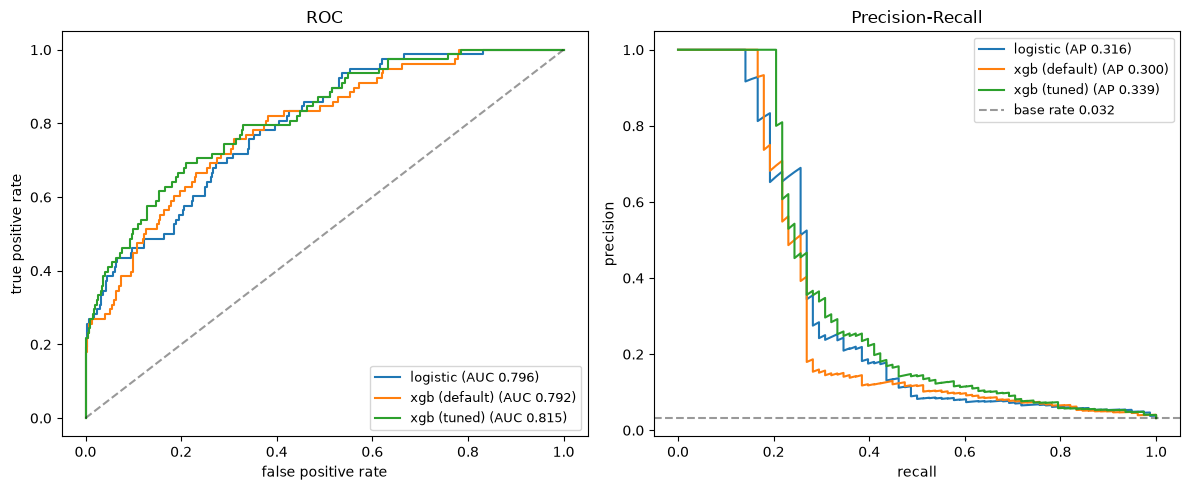

'figs/curves.png'

In [25]:
preds = {name: predict(X_val_estimate) for name, predict in model_dict.items()}
plot_curves(y_val_estimate, preds, 'figs/curves.png')

In [26]:
threshold = float(np.quantile(xgb_fine_tuned(X_val_select), 1 - CAPACITY))
point = operating_point(y_val_estimate, xgb_fine_tuned(val_estimate), threshold)

In [27]:
reliability(y_val_estimate, xgb_fine_tuned(val_estimate))

,n,mean_pred,observed
bin,,,
0,305,0.0186,0.0000
1,304,0.0190,0.0066
2,304,0.0194,0.0066
3,304,0.0202,0.0197
4,304,0.0216,0.0197
5,304,0.0236,0.0230
6,304,0.0270,0.0461
7,305,0.0812,0.1344


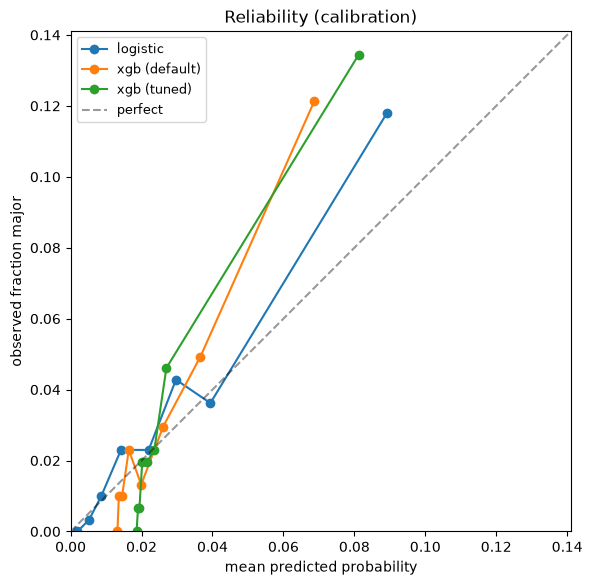

'figs/reliability.png'

In [28]:
preds = {name: predict(X_val_estimate) for name, predict in model_dict.items()}
plot_reliability(y_val_estimate, preds, path='figs/reliability.png')

### explainability

/opt/anaconda3/envs/stm-challenge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


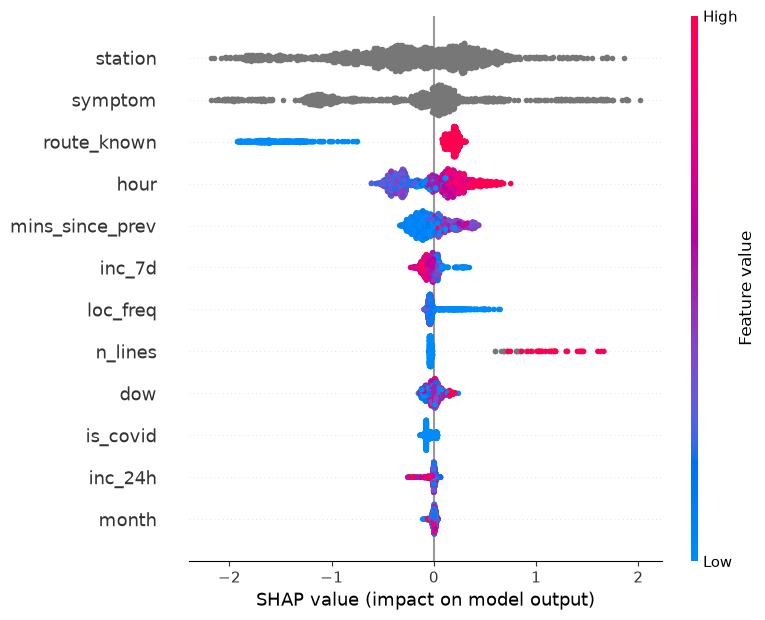

'shap.png'

In [ ]:
import shap
def shap_explain(predictor, background, path='figs/shap.png', max_display=12):
    """SHAP summary for a fitted XGBPredictor.
 
    Estimated on train/val data (passed in as `background`), never the holdout.
    Pulls the raw tree model out of the calibration wrapper which is required by 
    TreeExplainer needs and calibration is a monotone rescale on top that doesn't
    change which features drive a prediction.
    """
    import shap
    import matplotlib.pyplot as plt
 
    model = predictor.model
    # unwrap CalibratedClassifierCV -> the underlying XGBClassifier
    if hasattr(model, 'calibrated_classifiers_'):
        tree_model = model.calibrated_classifiers_[0].estimator
    else:
        tree_model = model
 
    X = predictor.preprocess(background)
    explainer = shap.TreeExplainer(tree_model)
    values = explainer.shap_values(X)
 
    shap.summary_plot(values, X, max_display=max_display, show=False)
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    return path

shap_explain(model_dict['xgb (tuned)'], val_estimate)


The model's decisions are driven mostly by where the incident is (station) and what type it is (symptom), with time of day and whether it hit multiple lines playing supporting roles. Those seem like sensible operational signals.
Hopefully the model is reacting to the things the Ops stakeholder would also weigh, not to some accidental quirk in the data.

## Financial Use Case

In [30]:
# Take the midpoint of each band as the minute equivalent 
MID = {'02 min and under': 1.5, '03 to 04 min': 3.5, '05 to 09 min': 7,
           '10 to 14 min': 12, '15 to 19 min': 17, '20 to 24 min': 22,
           '25 to 29 min': 27}
# Actual duration
clock_train = to_minutes(train.resumption_time) - train.start_min
clock_val = to_minutes(val.resumption_time) - val.start_min
clock_holdout = to_minutes(holdout.resumption_time) - holdout.start_min

## For 30 and over band use the lower value should be 30 or whatever the clock calculated for every other band it is the mid point
train['incident_minutes'] = np.where(train.incident_duration_band == '30 min and over',
                            clock_train.clip(lower=30),
                            train.incident_duration_band.map(MID))
val['incident_minutes'] = np.where(val.incident_duration_band == '30 min and over',
                            clock_val.clip(lower=30),
                            val.incident_duration_band.map(MID))

holdout['incident_minutes'] = np.where(holdout.incident_duration_band == '30 min and over',
                            clock_holdout.clip(lower=30),
                            holdout.incident_duration_band.map(MID))

## Recreate select and estimate 
val_select = val[val.service_day <= '2023-12-31']
X_val_select = val_select[FEATURES]
y_val_select = val[val.service_day <= '2023-12-31'].label

val_estimate = val[val.service_day >= '2024-01-01']
X_val_estimate = val_estimate[FEATURES]
y_val_estimate = val[val.service_day >= '2024-01-01'].label

### Learn Typical Durations

In [31]:
major_inc, minor_inc, fallback = severity_table(train, min_n=10)
major_inc

,n,median_inc_minutes,p90_inc_minutes
symptom,,,
customers,187,38.0,77.0
"fire, smoke, odour, substance, etc.",94,39.0,80.0
fixed equipment,106,42.0,137.5
rolling stock,44,33.0,70.2


### Blend typical durations with model probabiltiy
Per incident expected minutes 
$$\mathbb{E}[\text{minutes}] = P(\text{major}) \times \text{minutes}_{\text{if major}} + P(\text{minor}) \times \text{minutes}_{\text{if minor}}$$

In [32]:
tables = severity_table(train, min_n=10)
burden = expected_burden(val_estimate, xgb_fine_tuned(X_val_estimate), tables)
burden.head()


,p_major,expected_min,expected_min_p90
16439,0.018744,4.052953,4.750237
16440,0.020866,2.261625,3.075416
16441,0.021770,2.294601,3.143626
16442,0.025555,2.432750,3.429387
16443,0.024625,2.497293,4.848935


In [33]:
def decile_lift(predicted, actual, deciles=10):
    """Does the top predicted decile hold the most actual delay?
    """
    df = pd.DataFrame({'pred': np.asarray(predicted), 'actual': np.asarray(actual)})
    
    df['decile'] = pd.qcut(df.pred.rank(method='first'), deciles,
                          labels=range(deciles, 0, -1))
    
    out = df.groupby('decile', observed=True).agg(n=('actual', 'size'),
                                                 actual_min=('actual', 'sum'),
                                                 mean_pred=('pred', 'mean'))
    out['pct_of_total'] = (100 * out.actual_min / df.actual.sum()).round(1)
    return out.sort_index()

In [34]:
## If we can only respond to the top X% highest-risk predictions, 
# what percentage of total network disruption will we prevent?
decile_lift(burden.expected_min, val_estimate.incident_minutes)

,n,actual_min,mean_pred,pct_of_total
decile,,,,
10,244,509.0,2.179967,4.3
9,243,467.0,2.196650,3.9
8,243,632.5,2.225636,5.3
7,244,1141.0,2.279871,9.6
6,243,1108.5,2.346419,9.3
5,243,1111.5,2.441239,9.3
4,244,2433.5,2.619148,20.5
3,243,1564.0,3.442920,13.2
2,243,915.5,4.067458,7.7


### Linewise Incident Table
Decide where the money and attention should go

In [35]:
def burden_table(df, burden, pred_selector = 'expected_min',by='line_primary'):
    """Prioritisation table: predicted against actual minutes."""
    df = pd.DataFrame({by: df[by].astype(str).values,
                      'predicted': burden[pred_selector].values,
                      'actual': df.incident_minutes.values})
    
    out = df.groupby(by).agg(n=('actual', 'size'),
                            predicted_minutes=('predicted', 'sum'),
                            actual_minutes=('actual', 'sum'))
    
    out[['predicted_minutes', 'actual_minutes']] = out[['predicted_minutes', 'actual_minutes']].round(0)

    out['ratio'] = (out.predicted_minutes / out.actual_minutes).round(2)

    return out.sort_values('actual_minutes', ascending=False)

In [36]:
burden_table(val_estimate, burden, 'expected_min')


,n,predicted_minutes,actual_minutes,ratio
line_primary,,,,
orange,899,2527.0,5539.0,0.46
green,1074,3144.0,4756.0,0.66
blue,214,693.0,894.0,0.78
yellow,230,812.0,638.0,1.27
unassigned,17,58.0,60.0,0.97


In [37]:
burden_table(val_estimate, burden, 'expected_min_p90')

,n,predicted_minutes,actual_minutes,ratio
line_primary,,,,
orange,899,3754.0,5539.0,0.68
green,1074,4687.0,4756.0,0.99
blue,214,935.0,894.0,1.05
yellow,230,1032.0,638.0,1.62
unassigned,17,98.0,60.0,1.63


In [38]:
## Reading planned mileage data (line, service_day, planned_km)
km = pd.read_csv(MILEAGE_PATH, dtype=str)
km['service_day'] = pd.to_datetime(km.calendar_day)
km['planned_km'] = km.planned_mileage.astype(float)
mileage = km.groupby(['line', 'service_day'], as_index=False).planned_km.sum()

In [39]:
val_overlap = val[(val.service_day >= '2023-01-01') &
                  (val.service_day <= MILEAGE_END)]
X_val_overlap = val_overlap[FEATURES]

bpk_val, bpk_corr, bpk_corr_p90 = burden_per_km_validation(val_overlap, xgb_fine_tuned(X_val_overlap), tables, mileage)

On the overlap window, predicted burden-per-km ranks the four lines in exactly the same order as actual burden-per-km 
So the in theory we can claim "the model helps rank lines by delay burden"

But it is validated on one small window where validation is even possible
Caveats:
1. The magnitude is still biased low (predicted 21 or 29.6 vs actual 38 for green.)
2. Same median-vs-tail undershoot we've seen throughout: the severity table's p50 ignores the long tail that dominates actual minutes. Ranking transfers perfectly for both median and p90 but levels match better for p90

In [40]:
bpk_val

,actual_per_100k,pred_per_100k,pred_p90_per_100k,actual_rank,pred_rank,pred_p90_rank
green,38.1,20.6,29.8,1,1,1
blue,26.3,18.9,25.9,2,2,2
yellow,18.1,16.1,22.4,3,3,3
orange,16.1,11.3,16.2,4,4,4


## Safety Use Case

In [41]:
def get_major_safety_incidents(df):
    ''' Incidents over 30 min with evacuation or the involvement of
        the metro emergency team'''
    return df[(df.incident_duration_band == '30 min and over') &
              ((df.evacuation != 'N/A') | (df.emergency_metro == 'True'))].copy()


In [42]:
severe_safety_events = get_major_safety_incidents(train)
years = train.service_day.dt.year.nunique()
rows = []
for key, n in severe_safety_events.groupby('symptom', observed=True).size().sort_values(ascending=False).items():
    ## count rare events
    rows.append({'symptom': key, 'events': int(n), 'per_year': round(n / years, 1),})
pd.DataFrame(rows)

,symptom,events,per_year
0,customers,99,24.8
1,"fire, smoke, odour, substance, etc.",69,17.2
2,fixed equipment,44,11.0
3,rolling stock,25,6.2
4,station operations,2,0.5


In [43]:
### If the timestamps for these flags were known at start of incident time they could be included in the model

FLAG_FEATURES = ['evacuation', 'emergency_metro', 'material_damage', 'cat']

In [44]:
def prep_flags(d):
        out = d.copy()
        for c in FLAG_FEATURES:
            out[c] = out[c].astype(str).astype('category')
        return out

In [45]:
### Hypothetically if they are included

NEW_FEATURES = FEATURES + FLAG_FEATURES
X_hypo_train = prep_flags(train)[NEW_FEATURES]
X_hypo_eval = prep_flags(val_estimate)[NEW_FEATURES]
xgb_hypo = fit_xgb(X_hypo_train, y_train, features=NEW_FEATURES, categorical=CATEGORICAL+FLAG_FEATURES)


In [46]:
existing_pr_auc = evaluate(y_val_estimate, xgb_fine_tuned(X_val_estimate), 'existing')['pr_auc']
hypo_pr_auc = evaluate(y_val_estimate, xgb_hypo(X_hypo_eval), 'existing')['pr_auc']

In [ ]:
## Increased PR-AUC by 100% (double)
existing_pr_auc, hypo_pr_auc

(0.3392798225279103, 0.6668355774731967)

## Holdout Analysis

In [48]:
p_hold = xgb_fine_tuned(X_holdout)
holdout_scores = [
    evaluate(holdout.label, model_dict['logistic'](X_holdout), 'logistic'),
    evaluate(holdout.label, p_hold, 'xgb (tuned)'),
]
pd.DataFrame(holdout_scores).set_index('model').round(4)

## Difference is not significant

,pr_auc,roc_auc,brier
model,,,
logistic,0.2228,0.7885,0.0264
xgb (tuned),0.2223,0.7822,0.0264


In [49]:
point = operating_point(holdout.label, p_hold, threshold)
print('  flags %.1f%% | precision %.3f | recall %.3f | base rate %.3f'
        % (point['flagged_pct'], point['precision'], point['recall'],
            point['base_rate']))

print('\nreliability:\n%s' % reliability(holdout.label, p_hold).to_string())

  flags 4.7% | precision 0.184 | recall 0.285 | base rate 0.030

reliability:
       n  mean_pred  observed
bin                          
0    710     0.0186    0.0070
1    710     0.0189    0.0028
2    709     0.0191    0.0056
3    710     0.0197    0.0127
4    709     0.0208    0.0282
5    710     0.0230    0.0352
6    709     0.0266    0.0437
7    710     0.0738    0.1070


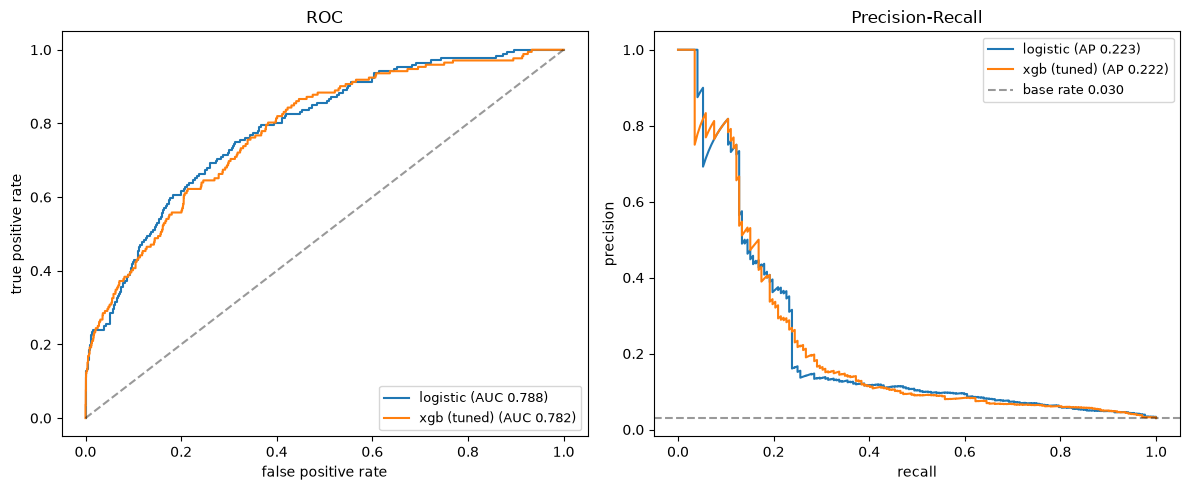

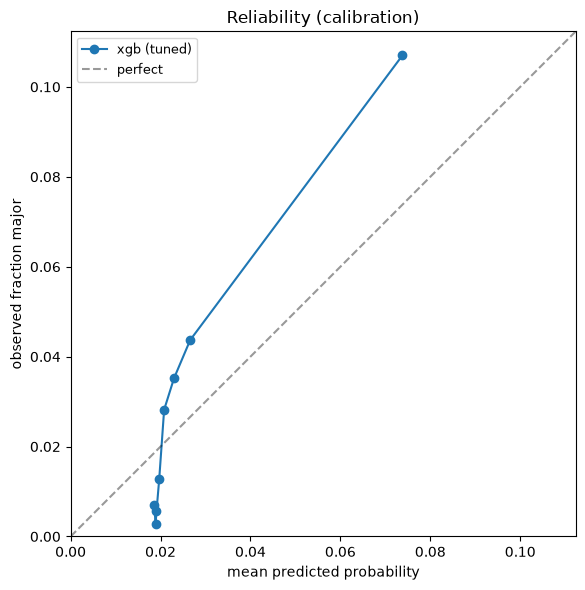

'figs/reliability_holdout.png'

In [50]:
plot_curves(holdout.label,{'logistic': model_dict['logistic'](X_holdout), 'xgb (tuned)': p_hold},
             path='figs/curves_holdout.png')
plot_reliability(holdout.label,{'xgb (tuned)': p_hold}, 
                    path='figs/reliability_holdout.png')

In [58]:
burden_holdout = expected_burden(holdout, p_hold, tables)
print('\ndecile lift on realised minutes:\n%s'
        % decile_lift(burden_holdout.expected_min, holdout.incident_minutes).to_string())

print('\ndecile lift on realised minutes (long tail):\n%s'
        % decile_lift(burden_holdout.expected_min_p90, holdout.incident_minutes).to_string())



decile lift on realised minutes:
          n  actual_min  mean_pred  pct_of_total
decile                                          
10      568      1243.0   2.180007           4.5
9       568      1162.0   2.197199           4.2
8       567      1788.5   2.234564           6.5
7       568      4327.0   2.306537          15.6
6       568      3032.0   2.401558          11.0
5       567      4365.5   2.552328          15.8
4       568      3503.5   3.154972          12.7
3       567      1590.5   4.054642           5.7
2       568      2204.5   4.068716           8.0
1       568      4468.5   5.615114          16.1

decile lift on realised minutes (long tail):
          n  actual_min  mean_pred  pct_of_total
decile                                          
10      568      1124.5   2.932459           4.1
9       568      1801.0   3.032944           6.5
8       567      1746.5   3.109173           6.3
7       568      2585.5   3.217884           9.3
6       568      3240.5   3.499367    

In [59]:
print('\nburden table linewise:\n%s'
        % burden_table(holdout, burden_holdout).to_string())



burden table linewise:
                 n  predicted_minutes  actual_minutes  ratio
line_primary                                                
green         2141             6574.0         10956.0   0.60
orange        2293             6827.0          9980.0   0.68
blue           664             2117.0          4493.0   0.47
yellow         555             1890.0          2220.0   0.85
unassigned      24               59.0            36.0   1.64


In [57]:
print('\nsevere events in holdout window: %d' % len(get_major_safety_incidents(holdout)))


severe events in holdout window: 85
